<a href="https://colab.research.google.com/github/Aryan-yadav7/ML_learning/blob/main/crop%20predictor%20multiple%20linear%20regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/content/FAOSTAT_data_en_8-17-2026.csv")

In [4]:
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,392,Japan,5312,Area harvested,113,Rice,1961,1961,ha,3312000.0,A,Official value,NaN
1,QCL,Crops and livestock products,392,Japan,5412,Yield,113,Rice,1961,1961,kg/ha,4879.4,A,Official value,NaN
2,QCL,Crops and livestock products,392,Japan,5510,Production,113,Rice,1961,1961,t,16160440.0,A,Official value,NaN
3,QCL,Crops and livestock products,392,Japan,5312,Area harvested,113,Rice,1962,1962,ha,3295000.0,A,Official value,NaN
4,QCL,Crops and livestock products,392,Japan,5412,Yield,113,Rice,1962,1962,kg/ha,5137.2,A,Official value,NaN


In [5]:
print(df.shape)

(192, 15)


In [6]:
print(df["Element"].unique())
print(df["Unit"].unique())

['Area harvested' 'Yield' 'Production']
['ha' 'kg/ha' 't']


In [7]:
#Reshaping the data
pivot_df = df.pivot(
    index="Year",
    columns="Element",
    values="Value"
)

print(pivot_df.head())

Element  Area harvested  Production   Yield
Year                                       
1961          3312000.0  16160440.0  4879.4
1962          3295000.0  16927100.0  5137.2
1963          3276000.0  16648830.0  5082.1
1964          3264000.0  16356100.0  5011.1
1965          3258500.0  16126060.0  4948.9


In [8]:
pivot_df = pivot_df.reset_index()

print(pivot_df.head())

Element  Year  Area harvested  Production   Yield
0        1961       3312000.0  16160440.0  4879.4
1        1962       3295000.0  16927100.0  5137.2
2        1963       3276000.0  16648830.0  5082.1
3        1964       3264000.0  16356100.0  5011.1
4        1965       3258500.0  16126060.0  4948.9


In [10]:
pivot_df = pivot_df.rename(columns={
    "Area harvested": "area_harvested",
    "Production": "production",
    "Yield": "yield"
})
print(pivot_df.head())

Element  Year  area_harvested  production   yield
0        1961       3312000.0  16160440.0  4879.4
1        1962       3295000.0  16927100.0  5137.2
2        1963       3276000.0  16648830.0  5082.1
3        1964       3264000.0  16356100.0  5011.1
4        1965       3258500.0  16126060.0  4948.9


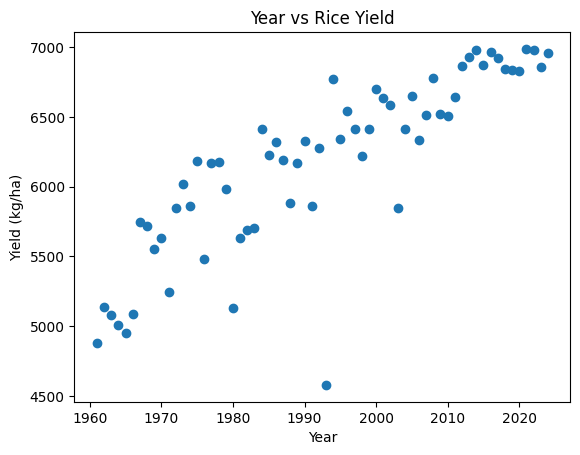

In [11]:
plt.scatter(
    pivot_df["Year"],
    pivot_df["yield"]
)

plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.title("Year vs Rice Yield")

plt.show()

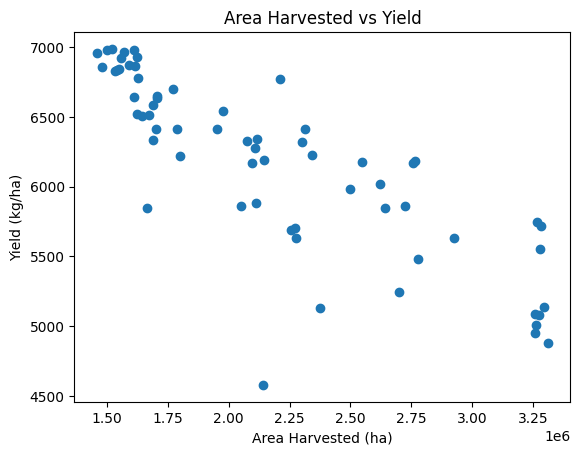

In [12]:
plt.scatter(
    pivot_df["area_harvested"],
    pivot_df["yield"]
)

plt.xlabel("Area Harvested (ha)")
plt.ylabel("Yield (kg/ha)")
plt.title("Area Harvested vs Yield")

plt.show()

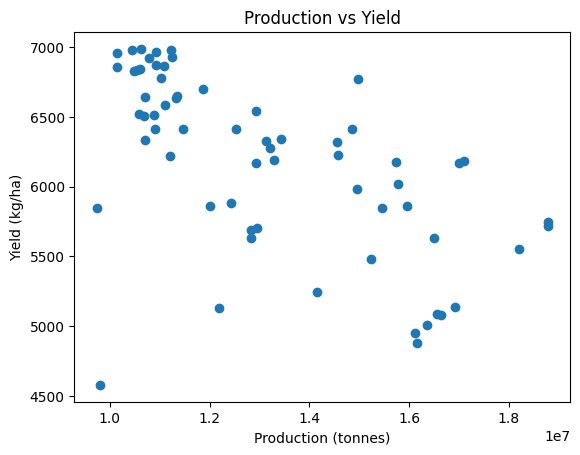

In [13]:
plt.scatter(
    pivot_df["production"],
    pivot_df["yield"]
)

plt.xlabel("Production (tonnes)")
plt.ylabel("Yield (kg/ha)")
plt.title("Production vs Yield")

plt.show()

In [14]:
print(pivot_df[
    ["Year", "area_harvested", "production", "yield"]
].corr())

Element             Year  area_harvested  production     yield
Element                                                       
Year            1.000000       -0.958809   -0.894657  0.848344
area_harvested -0.958809        1.000000    0.942667 -0.819161
production     -0.894657        0.942667    1.000000 -0.596079
yield           0.848344       -0.819161   -0.596079  1.000000


In [16]:
X = pivot_df[
    ["Year", "area_harvested", "production"]
]

y = pivot_df["yield"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()


In [19]:
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -34502.71770143264
Coefficients: [ 1.98387761e+01 -1.86504354e-03  3.95709200e-04]


In [22]:
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Year : 19.83877610104164
area_harvested : -0.0018650435396246909
production : 0.00039570919975077663


In [25]:
errors = y_test - y_pred

squared_errors = errors**2

sum = 0
for i in squared_errors:
  sum = sum + i

n = X_test.shape[0]

mse = sum/n
print(mse)

10357.23159082977


In [26]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 101.77048487076088


In [27]:
errors = y_test - y_pred

absolute_errors = abs(errors)

total = 0
for i in absolute_errors:
  total = total + i

n = X_test.shape[0]

mae = total/n

print("MAE: ", mae)

MAE:  74.61358473665656


In [28]:
errors = y_test - y_pred

# Sum of squared errors
ss_res = 0
for i in errors:
    ss_res += i ** 2

# Mean of actual test values
mean_y = y_test.mean()

# Total sum of squares
ss_tot = 0
for i in y_test:
    ss_tot += (i - mean_y) ** 2

r2 = 1 - (ss_res / ss_tot)

print("R²:", r2)

R²: 0.9767927905276229


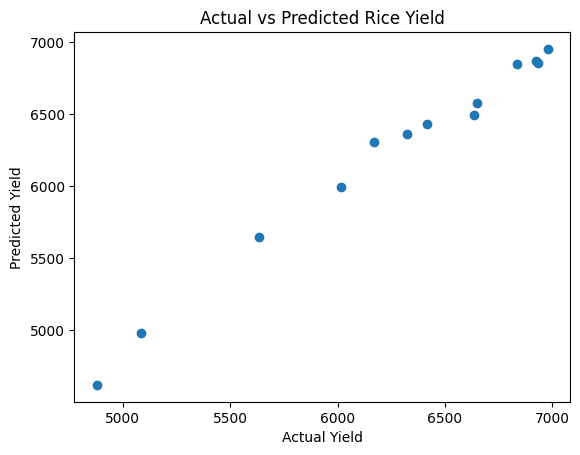

In [29]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Rice Yield")

plt.show()

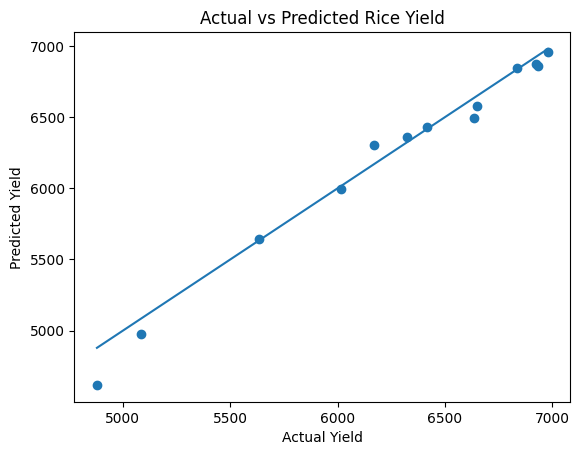

In [30]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Rice Yield")

plt.show()